In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
#from passwords import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import datetime as dt

try:
    import catboost
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-05-06 21:49:16.286561


### Functions

In [3]:
# # download from s3
# def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
#     # init client
#     cls_client = boto3.client(
#         's3',
#         aws_access_key_id=aws_access_key_id,
#         aws_secret_access_key=aws_secret_access_key,
#     )
#     # download file
#     cls_client.download_file(
#         str_project, 
#         str_bucket_path, 
#         str_local_path,
#     )

In [4]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [5]:
# # upload to s3
# def upload_to_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_key, str_bucket_name):
#     # init client
#     cls_client = boto3.client(
#         's3',
#         aws_access_key_id=aws_access_key_id,
#         aws_secret_access_key=aws_secret_access_key,
#         aws_session_token=None,
#     )
#     # upload
#     cls_client.upload_file(
#         str_local_path, 
#         str_bucket_name, 
#         str_bucket_key,
#     )

In [6]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
        aws_session_token=None,
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

In [7]:
# plot distribution
def plot_distribution(ser_values, str_sername, str_dirname_output, str_filename):
    # get min/max
    flt_min = ser_values.min()
    flt_max = ser_values.max()
    flt_mean = ser_values.mean()
    flt_std = ser_values.std()
    flt_mdn = ser_values.median()
    # show distribution
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of {str_sername.split('_')[-1].upper()} - Production 
    N = {len(ser_values)}; Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mean = {flt_mean:0.2f}; Std = {flt_std:0.2f}; Mdn = {flt_mdn:0.2f}
    """
    ax.set_title(str_title)
    sns.distplot(list(ser_values), ax=ax)
    # save
    plt.savefig(f'{str_dirname_output}/{str_filename}', bbox_inches='tight')
    # show
    plt.show()

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel10'

Project: 20231010-gen-xii
Task: 08_retro_scoring


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [10]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get data

In [11]:
%%time

# download
str_filename = 'df.gzip'
str_local_path = f'./{str_filename}'
str_bucket_path = f'{str_task}/06_create_df/{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import
df = pd.read_parquet(str_local_path)
# rm
os.remove(str_local_path)

# convert to datetime
df['applicationdate__app'] = pd.to_datetime(df['applicationdate__app'])

# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df.drop(list_cols, axis=1, inplace=True)

# get features 100% NaN and drop
ser_isnull = df.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
# logic
if str_variant == 'model3':
    list_all_nan = [col for col in list_all_nan if col != 'cvlst_s1__tu']
else:
    pass
df.drop(list_all_nan, axis=1, inplace=True)

# show
df

CPU times: user 5.87 s, sys: 2.75 s, total: 8.62 s
Wall time: 2.93 s


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,...,fltdowncash__app,fltapproveddowntotal__app,payment__app,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app
0,0__0__20210120,14.0,Stanley,Virginia,22851,False,0.0,False,1,1,...,0.0,0.00,412.34,0.307483,0.103700,0,1.149789,suv,1,2011-06-30 10:15:42.320
1,0__0__20210120,14.0,Austin,Texas,78727,False,0.0,False,1,1,...,250.0,105.06,638.00,0.233488,0.132294,0,1.100576,suv,0,2012-10-19 15:20:30.163
2,0__0__20210122,14.0,STOCKTON,California,95207,False,0.0,False,1,1,...,1000.0,1000.00,629.99,0.340494,0.140493,0,1.051327,suv,1,2020-07-06 17:09:57.383
3,0__0__20210123,14.0,Mount Orab,Ohio,45154,False,0.0,False,1,1,...,0.0,0.00,398.95,0.481666,0.070066,0,1.143705,auto,0,2016-11-16 16:28:03.170
4,0__0__20210123,14.0,Mount Orab,Ohio,45154,False,0.0,False,1,1,...,0.0,0.00,398.95,0.481666,0.070066,0,1.143705,auto,0,2016-11-16 16:28:03.170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71184,0__0__20231109,5.0,FOREST HILL,Texas,76119,False,0.0,False,11,4,...,0.0,0.00,511.77,0.449811,0.122139,0,1.349948,suv,0,2008-02-20 11:14:02.013
71185,0__0__20231120,5.0,CHICAGO,Illinois,60629,False,0.0,False,11,4,...,1000.0,500.00,450.63,0.350022,0.150022,0,1.149932,suv,0,2013-05-08 08:47:59.997
71186,0__0__20231107,1.0,PIKESVILLE,Maryland,21208,False,0.0,False,11,4,...,500.0,1000.00,727.74,0.385896,0.058485,1,0.838573,suv,0,2023-05-03 15:53:03.583
71187,0__0__20231117,5.0,Saginaw,Michigan,48601,False,0.0,False,11,4,...,0.0,0.00,587.21,0.453596,0.128596,0,1.121384,suv,1,2017-07-26 16:22:04.930


### Get preprocessor

In [12]:
%%time

list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

100%|██████████| 2/2 [00:00<00:00,  8.80it/s]

CPU times: user 146 ms, sys: 10.2 ms, total: 157 ms
Wall time: 262 ms


### Preprocess data

In [13]:
%%time

df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

NaN Replacer: 0.49214 sec.


100%|██████████| 3/3 [00:00<00:00, 83.00it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.03806 sec.


Boolean Replacer: 1.5055 sec.


100%|██████████| 1987/1987 [00:01<00:00, 1567.20it/s]


...


100%|██████████| 1992/1992 [00:01<00:00, 1169.58it/s]


Replace inf and -inf with NaN: 2.0382 sec.
Imputer: 1.116 sec.
Map term: 0.036893 sec.
Map PTI: 0.04086 sec.


100%|██████████| 9/9 [00:00<00:00, 1292.81it/s]

Round values: 0.010172 sec.
Preprocessing Model: 10.664 sec.
CPU times: user 8.71 s, sys: 1.98 s, total: 10.7 s
Wall time: 10.7 s


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,...,bitgap__app,dealerstampcreation__app,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,0__0__20210120,14.0,stanley,virginia,22851,0.0,0.0,0.0,1.0,1.0,...,1,2011-06-30 10:15:42.320,2021,1.080027,1,1,0.09,1.269231,5.0,9.567123
1,0__0__20210120,14.0,austin,texas,78727,0.0,0.0,0.0,1.0,1.0,...,0,2012-10-19 15:20:30.163,2021,1.080027,1,1,0.12,1.153846,0.0,8.260274
2,0__0__20210122,14.0,stockton,california,95207,0.0,0.0,0.0,1.0,1.0,...,1,2020-07-06 17:09:57.383,2021,1.080027,1,1,0.12,1.215686,3.0,0.547945
3,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,0,2016-11-16 16:28:03.170,2021,1.080027,1,1,0.06,1.250000,4.0,4.186301
4,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,0,2016-11-16 16:28:03.170,2021,1.080027,1,1,0.15,1.250000,4.0,4.186301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71184,0__0__20231109,5.0,foresthill,texas,76119,0.0,0.0,0.0,11.0,4.0,...,0,2008-02-20 11:14:02.013,2023,0.970000,11,4,0.12,1.464286,7.0,15.726027
71185,0__0__20231120,5.0,chicago,illinois,60629,0.0,0.0,0.0,11.0,4.0,...,0,2013-05-08 08:47:59.997,2023,0.970000,11,4,0.12,1.269231,6.0,10.542466
71186,0__0__20231107,1.0,pikesville,maryland,21208,0.0,0.0,0.0,11.0,4.0,...,0,2023-05-03 15:53:03.583,2023,0.970000,11,4,0.03,1.034483,3.0,0.512329
71187,0__0__20231117,5.0,saginaw,michigan,48601,0.0,0.0,0.0,11.0,4.0,...,1,2017-07-26 16:22:04.930,2023,0.970000,11,4,0.12,1.250000,5.0,6.312329


### Get models

In [14]:
list_str_model = [
    '01_ad',
    '02_pricing_pd',
    '03_pricing_lgd',
]
dict_models = {}
for str_model in tqdm(list_str_model):
    # download model
    str_filename = f'final_model.pkl'
    str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    # import model
    cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
    # rm
    os.remove(str_local_path)
    # assign to dictionary
    dict_models[str_model] = cls_model_inference

100%|██████████| 3/3 [00:00<00:00,  3.33it/s]


### Generate predictions

In [15]:
%%time

list_str_colname = []
for str_model, cls_model_inference in dict_models.items():
    print(f'Generating predictions for {str_model}...')
    # get cols in model
    list_cols_model = list(cls_model_inference.feature_names_)
    # create col name
    str_colname = f'yhat_{str_model[3:]}'
    # append
    list_str_colname.append(str_colname)
    # predict
    if 'lgd' in str_model:
        df[str_colname] = cls_model_inference.predict(df[list_cols_model])
    else:
        df[str_colname] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

Generating predictions for 01_ad...
Generating predictions for 02_pricing_pd...
Generating predictions for 03_pricing_lgd...
CPU times: user 1.25 s, sys: 33.5 ms, total: 1.28 s
Wall time: 369 ms


,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,bitfunded__app,applicationmonth__app,applicationquarter__app,...,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_ad,yhat_pricing_pd,yhat_pricing_lgd
0,0__0__20210120,14.0,stanley,virginia,22851,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.09,1.269231,5.0,9.567123,0.454956,0.457796,0.637971
1,0__0__20210120,14.0,austin,texas,78727,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.12,1.153846,0.0,8.260274,0.533774,0.384922,0.643923
2,0__0__20210122,14.0,stockton,california,95207,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.12,1.215686,3.0,0.547945,0.164688,0.132439,0.634524
3,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.06,1.250000,4.0,4.186301,0.527373,0.294455,0.645909
4,0__0__20210123,14.0,mountorab,ohio,45154,0.0,0.0,0.0,1.0,1.0,...,1.080027,1,1,0.15,1.250000,4.0,4.186301,0.587717,0.501850,0.660393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71184,0__0__20231109,5.0,foresthill,texas,76119,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.464286,7.0,15.726027,0.195260,0.200474,0.685285
71185,0__0__20231120,5.0,chicago,illinois,60629,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.269231,6.0,10.542466,0.216180,0.320133,0.687840
71186,0__0__20231107,1.0,pikesville,maryland,21208,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.03,1.034483,3.0,0.512329,0.088405,0.053891,0.606810
71187,0__0__20231117,5.0,saginaw,michigan,48601,0.0,0.0,0.0,11.0,4.0,...,0.970000,11,4,0.12,1.250000,5.0,6.312329,0.496780,0.318006,0.776057


### Get grouped scores at the account level

In [16]:
df_tmp = df.groupby(by='bigAccountId', as_index=False).agg({
    'yhat_ad': 'mean',
    'yhat_pricing_pd': 'mean',
    'yhat_pricing_lgd': 'mean',
})

# ecnl
str_colname = 'pricing_ecnl'
if str_variant == 'noPTImodel10':
    df_tmp[str_colname] = (df_tmp['yhat_pricing_pd'] * df_tmp['yhat_pricing_lgd']) * 2.36
else:
    df_tmp[str_colname] = (df_tmp['yhat_pricing_pd'] * df_tmp['yhat_pricing_lgd'])

# append
list_str_colname.append(str_colname)

# show
df_tmp

,bigAccountId,yhat_ad,yhat_pricing_pd,yhat_pricing_lgd,pricing_ecnl
0,5514485,0.454956,0.457796,0.637971,0.689263
1,5514970,0.440640,0.118641,0.649063,0.181733
2,5515245,0.533774,0.384922,0.643923,0.584950
3,5515340,0.485115,0.236593,0.640644,0.357709
4,5515580,0.500847,0.290466,0.629329,0.431404
...,...,...,...,...,...
58426,7373944,0.484931,0.177340,0.680696,0.284887
58427,7373949,0.445935,0.293760,0.627291,0.434884
58428,7373986,0.155877,0.096083,0.647022,0.146717
58429,7374018,0.237313,0.121283,0.669731,0.191695


### Write unaggregated data to s3

In [17]:
%%time

# set dtype as string
for col in tqdm(df.columns):
    if df[col].dtype not in ['int64','float64']:
        df[col] = df[col].astype(str)

str_filename = 'df_retro_predictions.gzip'
str_local_path = f'./{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

# upload
str_bucket_key = f'08_retro_scoring/07_analysis/{str_variant}/{str_filename}'
upload_to_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_key=str_bucket_key, 
    str_bucket_name=str_project,
)
# rm
os.remove(str_local_path)

100%|██████████| 2021/2021 [00:00<00:00, 4942.65it/s] 


CPU times: user 22.4 s, sys: 468 ms, total: 22.8 s
Wall time: 23.4 s


### Make plots

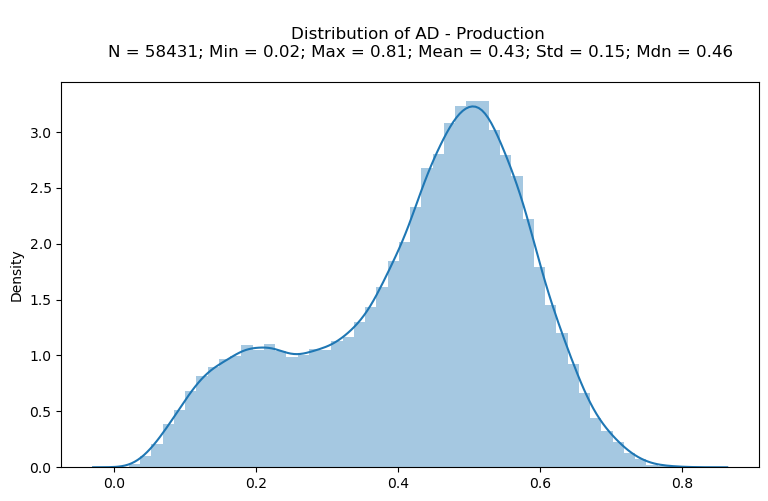

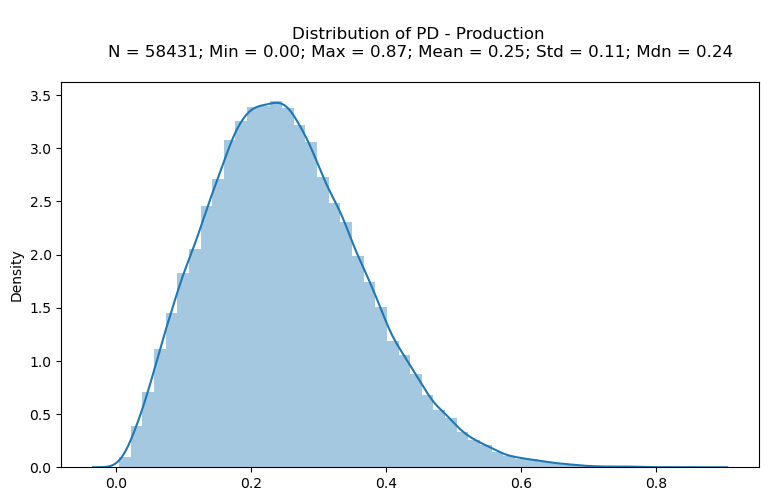

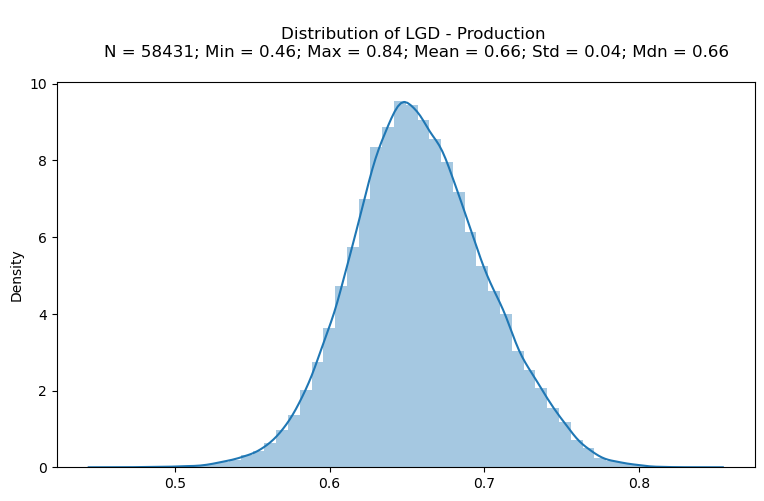

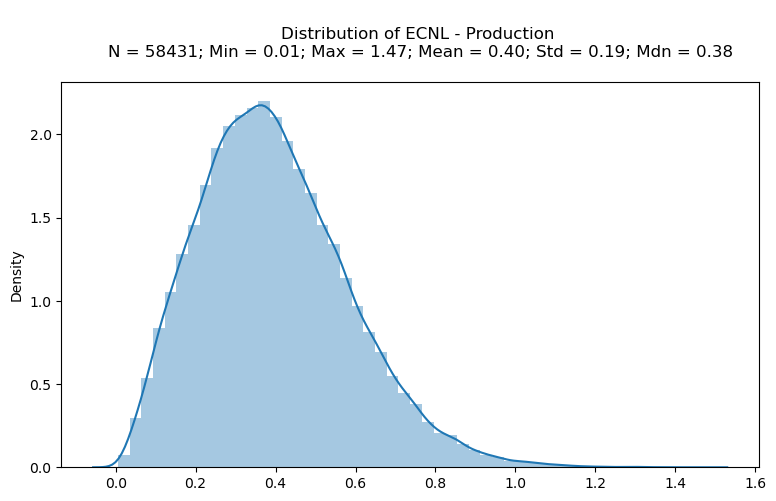


CPU times: user 5.11 s, sys: 135 ms, total: 5.25 s
Wall time: 2.92 s


In [18]:
%%time

for col in list_str_colname:
    plot_distribution(
        ser_values=df_tmp[col], 
        str_sername=col, 
        str_dirname_output=f'{str_dirname_output}/{str_variant}', 
        str_filename=f'plt_dist_{col}.png',
    )
    print('')